In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Загрузка исторических данных

name = "BTCUSDT_1h_last_year"
filename = f"data/1h_last_year/{name}.csv"
data = pd.read_csv(filename, parse_dates=['timestamp'])
data.set_index('timestamp', inplace=True)
data.drop(['open', 'high', 'low', 'close_time', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_volume', 'taker_buy_quote_volume', 'ignore'], axis=1, inplace=True)

C:\Users\AESoldatov\AppData\Local\Temp\ipykernel_14220\2883180613.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.plot(plot_data[data['signal'] == 1]['close'],
C:\Users\AESoldatov\AppData\Local\Temp\ipykernel_14220\2883180613.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.plot(plot_data[data['signal'] == -1]['close'],


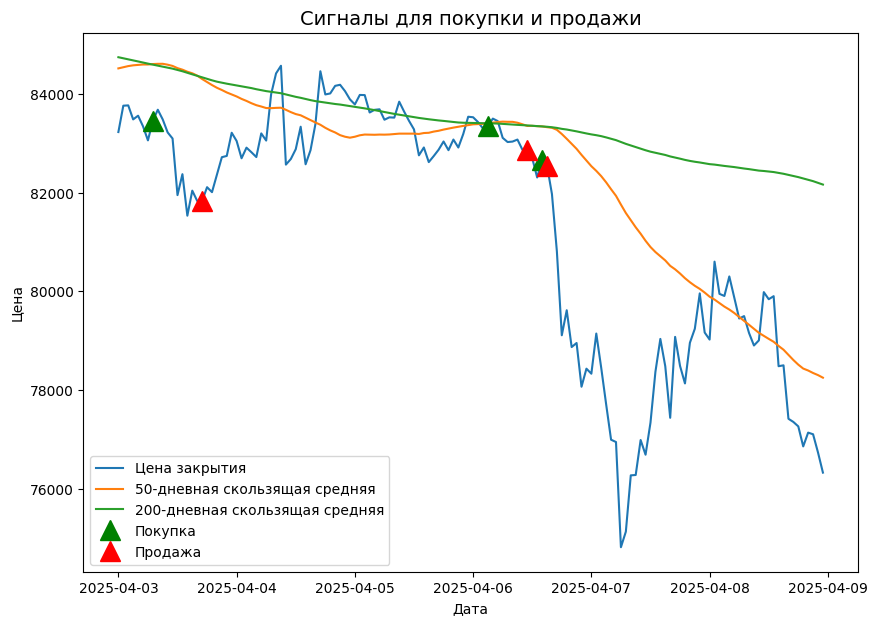

In [4]:
# Стратегия

short_window = 200
long_window = 50

data['SMA200'] = data['close'].rolling(window=short_window).mean()
data['SMA50'] = data['close'].rolling(window=long_window).mean()

# Сигналы для покупки

data['buy'] = np.where((data['SMA50'] >= data['SMA200']) & (data['SMA50'].shift(1) <= data['SMA200'].shift(1)), 1, 0)

# Сигналы для продажи
data['sell'] = np.where((data['SMA50'] <= data['SMA200']) & (data['SMA50'].shift(1) >= data['SMA200'].shift(1)), -1, 0)

data['signal'] = data['buy'] + data['sell']

plot_data = data['2025-04-03': '2025-04-08']
plt.figure(figsize=(10, 7))
plt.title('Сигналы для покупки и продажи', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.plot(plot_data['close'], label='Цена закрытия')
plt.plot(plot_data['SMA50'], label='50-дневная скользящая средняя')
plt.plot(plot_data['SMA200'], label='200-дневная скользящая средняя')
plt.plot(plot_data[data['signal'] == 1]['close'],
'^', ms=15, label='Покупка', color='green')
plt.plot(plot_data[data['signal'] == -1]['close'],
'^', ms=15, label='Продажа', color='red')
plt.legend()
plt.show()

In [19]:
portfolio = pd.DataFrame(data=data['signal'], index=data.index)

initial_portfolio_value = 100000
buy_percentage = 0.1
buy_mask = data['signal'].shift(1).fillna(0) == 1
sell_mask = data['signal'].shift(1).fillna(0) == -1

portfolio['portfolio_value'] = initial_portfolio_value
portfolio['investment_amount'] = 0
portfolio['shares_held'] = 0
portfolio['sale_proceeds'] = 0
portfolio['shares_sold'] = 0

# Шаг 1. Расчёт покупок
portfolio['investment_amount'] = np.where(
    buy_mask,
    portfolio['portfolio_value'].shift(1).fillna(initial_portfolio_value) * buy_percentage,
    0
)
portfolio['shares_bought'] = np.where(
    buy_mask,
    portfolio['investment_amount'] / data['close'],
    0
)

cumulative_bought = portfolio['shares_bought'].cumsum()
# Общее количество проданных акций (кумулятивно)
# cumulative_sold = portfolio['shares_sold'].cumsum()
# portfolio['cumulative_sold'] = cumulative_sold
# # Текущее количество акций на руках
# portfolio['shares_held'] = cumulative_bought - cumulative_sold

# Шаг 2. Расчёт продаж
portfolio['shares_sold'] = np.where(
    sell_mask,
    cumulative_bought.shift(1).fillna(0),
    0
)
# Выручка от продажи
portfolio['sale_proceeds'] = np.where(
    sell_mask,
    portfolio['shares_sold'] * data['close'],
    0
)

# Общее количество купленных акций (кумулятивно)
cumulative_bought = portfolio['shares_bought'].cumsum()
portfolio['cumulative_bought'] = cumulative_bought
# Общее количество проданных акций (кумулятивно)
cumulative_sold = portfolio['shares_sold'].cumsum()
portfolio['cumulative_sold'] = cumulative_sold
# Текущее количество акций на руках
portfolio['shares_held'] = cumulative_bought - cumulative_sold
#
# Шаг 4. Расчёт денежных средств
# Деньги от продаж (кумулятивно)
total_sale_proceeds = portfolio['sale_proceeds'].cumsum()
# Деньги, потраченные на покупки (кумулятивно)
total_investments = portfolio['investment_amount'].cumsum()
#
# Денежный баланс: начальная сумма + продажи − покупки
portfolio['cash_balance'] = (
    initial_portfolio_value +
    total_sale_proceeds -
    total_investments
)

# Шаг 5. Расчёт стоимости портфеля
# Стоимость акций на текущем шаге
portfolio['stock_value'] = portfolio['shares_held'] * data['close']
# Итоговая стоимость портфеля: деньги + акции
portfolio['portfolio_value'] = portfolio['cash_balance'] + portfolio['stock_value']

portfolio['2025-04-03': '2025-04-15'].head(20)
#portfolio['2025-03-29': '2025-04-15'].head(20)
#portfolio['2025-04-06': '2025-09-15'].head(20)

,signal,portfolio_value,investment_amount,shares_held,sale_proceeds,shares_sold,shares_bought,cumulative_bought,cumulative_sold,cash_balance,stock_value
timestamp,,,,,,,,,,,
2025-04-03 00:00:00,0,100000.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100000.000000,0.000000
2025-04-03 01:00:00,0,100000.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100000.000000,0.000000
2025-04-03 02:00:00,0,100000.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100000.000000,0.000000
2025-04-03 03:00:00,0,100000.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100000.000000,0.000000
2025-04-03 04:00:00,0,100000.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100000.000000,0.000000
2025-04-03 05:00:00,0,100000.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100000.000000,0.000000
2025-04-03 06:00:00,0,100000.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100000.000000,0.000000
2025-04-03 07:00:00,1,100000.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100000.000000,0.000000
2025-04-03 08:00:00,0,100000.000000,10000.0,0.119503,0.000000,0.000000,0.119503,0.119503,0.000000,90000.000000,10000.000000


In [27]:
"""
Векторизованный расчёт стоимости портфеля.
close : pd.Series — цены закрытия
signal : pd.Series — сигналы: 1 (покупка), -1 (продажа), 0 (ничего)
initial_capital : float
"""
initial_capital = 10000
portfolio2 = pd.DataFrame(data=data[['signal', 'close']], index=data.index)

# 1. Присваиваем номер сделки: увеличивается при сигнале покупки
portfolio2['trade_id'] = (portfolio2['signal'] == 1).cumsum()
# Но нужно, чтобы номер сделки был у всех строк от покупки до следующей покупки (или конца)
# Для этого заполняем вперёд (ffill) и обнуляем до первой покупки
#portfolio2['trade_id'] = portfolio2['trade_id'].replace(0, np.nan).ffill().fillna(0).astype(int)

# 2. Для каждой сделки определяем цену покупки (первое значение close в группе)
# Цена покупки постоянна для всей группы
portfolio2['buy_price'] = portfolio2.groupby('trade_id')['close'].transform('first')

# 3. Вычисляем множитель для каждого дня внутри сделки:
#    внутри цикла (между покупкой и продажей) множитель = 0.9 + 0.1 * (close / buy_price)
#    после продажи множитель становится константой (равной значению на день продажи)
# Для этого сначала зададим множитель везде как 1 (для дней без сделок)
portfolio2['multiplier'] = 1.0

# Для групп с trade_id > 0 (активные сделки) вычисляем динамический множитель
mask_active = portfolio2['trade_id'] > 0
portfolio2.loc[mask_active, 'multiplier'] = 0.9 + 0.1 * portfolio2.loc[mask_active, 'close'] / portfolio2.loc[mask_active, 'buy_price']

# 4. После продажи (сигнал -1) множитель должен оставаться постоянным до следующей покупки
# Найдём индексы продаж
sell_idx = portfolio2[portfolio2['signal'] == -1].index
for idx in sell_idx:
    # Значение множителя в день продажи
    val = portfolio2.loc[idx, 'multiplier']
    # Найти следующий индекс после idx, где signal == 1 (следующая покупка)
    next_buy = portfolio2[(portfolio2.index > idx) & (portfolio2['signal'] == 1)].index.min()
    if pd.isna(next_buy):
        next_buy = portfolio2.index[-1] + 1  # до конца
    # Заполняем множителем val на интервале (idx, next_buy)
    portfolio2.loc[idx:next_buy, 'multiplier'] = val

# 5. Кумулятивное произведение множителей даёт итоговую стоимость портфеля
portfolio2['portfolio'] = initial_capital * portfolio2['multiplier'].cumprod()

portfolio2['2025-04-03': '2025-04-15'].head(20)
portfolio2['2025-04-06': '2025-09-15'].head(20)

,signal,close,trade_id,buy_price,multiplier,portfolio
timestamp,,,,,,
2025-04-06 00:00:00,0,83527.22,1,83456.75,0.998051,8880.341944
2025-04-06 01:00:00,0,83428.97,1,83456.75,0.998051,8863.032371
2025-04-06 02:00:00,0,83300.01,1,83456.75,0.998051,8845.756537
2025-04-06 03:00:00,1,83344.14,2,83344.14,0.998051,8828.514377
2025-04-06 04:00:00,0,83499.99,2,83344.14,1.000187,8830.165272
2025-04-06 05:00:00,0,83450.01,2,83344.14,1.000127,8831.286946
2025-04-06 06:00:00,0,83110.24,2,83344.14,0.999719,8828.808502
2025-04-06 07:00:00,0,83024.96,2,83344.14,0.999617,8825.427365
2025-04-06 08:00:00,0,83034.26,2,83344.14,0.999628,8822.146003


In [6]:
# Расчет дневной доходности
data['Returns'] = data['close'].resample('D').last().pct_change()
print(f"Средняя дневная доходность: {data['Returns'].mean()*100:.4f}%")
print(f"Волатильность: {data['Returns'].std()*100:.3f}%")

Средняя дневная доходность: -0.0170%
Волатильность: 2.311%


In [7]:
initial_capital = 10000

data['returns'] = data['close'].pct_change()
data['strategy_returns'] = data['signal'].shift(1) * data['returns']
data['equity'] = (1 + data['strategy_returns']).cumprod() * initial_capital

# Вычисляем метрики эффективности
total_return = (data['equity'].iloc[-1] / initial_capital - 1) * 100
annualized_return = (data['equity'].iloc[-1] / initial_capital) ** (252 / len(data)) - 1
annualized_return *= 100

sharpe_ratio = data['strategy_returns'].mean() / data['strategy_returns'].std() * np.sqrt(252)
max_drawdown = (data['equity'] / data['equity'].cummax() - 1).min() * 100

print(f"Общая доходность: {total_return:.2f}%")
print(f"Годовая доходность: {annualized_return:.2f}%")
print(f"Коэффициент Шарпа: {sharpe_ratio:.2f}")
print(f"Максимальная просадка: {max_drawdown:.2f}%")

Общая доходность: -2.29%
Годовая доходность: -0.07%
Коэффициент Шарпа: -0.11
Максимальная просадка: -4.55%


In [8]:
data['Returns'] = data['close'].pct_change()
# Моделирование результатов стратегии
data['Strategy_Returns'] = data['signal'].shift(1) * data['Returns']
data['Cumulative_Strategy_Returns'] = (1 + data['Strategy_Returns']).cumprod()
data['Cumulative_Market_Returns'] = (1 + data['Returns']).cumprod()

# Сравнение результатов
print(f"Общая доходность стратегии: {(data['Cumulative_Strategy_Returns'].iloc[-1] - 1) * 100:.2f}%")
print(f"Общая доходность рынка: {(data['Cumulative_Market_Returns'].iloc[-1] - 1) * 100:.2f}%")

Общая доходность стратегии: -2.29%
Общая доходность рынка: -14.95%
